
## STOCHASTIC MODELING
MODULE 7 | LESSON 1


---

# **Basic Graph Representations**

|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** | Python, matplotlib, data representation |
|**Keywords** | Graph theory, complex networks


---

Welcome to the last module of Stochastic Modeling. This module is a little bit disconnected from what we have been doing so far, but serves as a good introduction for what's to come in future courses such as Deep Learning for finance. The idea of the module is introducing **Network Theory**, which is a helpful topic to unveil complex relationships in the empirical data. In this first lesson we will go over the main concepts in graph theory, and illustrate some relationships with data visualizations and some convenient metrics using synthetic data.

The following notebooks aim to give you a practical approach on the different matters. For the theory side, we will be closely following the book by Prof. Albert-Laszlo Barabasi *Network Science*. This lesson focus mostly on topics on Chapter 2 of the book. You can read the book online for free here: https://networksciencebook.com/

As usual, our first step is to import the necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from IPython.display import display

np.random.seed(42)



## **1. Basic graph representation**

A crucial part of understanding any complex system is to know how its components interact with eachother. For that, graph representation is an important help. Here, we introduce the main concepts required to understand how to construct and "read" graphs. Note that the terms network and graph are used interchangeably.

**What is a graph?**

A **graph** is a mathematical object used to represent pairwise relationships between entities.  
Formally, a graph is defined as:

$$
G = (V, E)
$$

where:  
- $V$ is the set of **vertices** (or **nodes**), representing entities.  
- $E$ is the set of **edges**, representing relationships or connections between pairs of vertices.

Each edge $e \in E$ connects one or more vertices in $V$.

Graphs provide a powerful abstraction for representing **networks** — systems where entities interact — such as:

- People in **social networks**  
- Computers on the **internet**  
- Stocks in **financial markets**  
- Banks in **lending networks**

In network theory, the structure of a graph encodes how information, value, or influence moves between the components of a system. There are, as you might expect, different types of graphs:



### **1.1. Simple Graphs**

A **simple graph** is the most basic type of graph:

$$
G = (V, E)
$$

such that:

- It is **undirected**: if $(u, v) \in E$, then $(v, u) \in E$ implicitly.  
- It has **no self-loops**: $(v, v) \notin E$ for all $v \in V$.  
- It has **no multiple (parallel) edges** between the same pair of nodes.

In a simple graph, an edge represents a **symmetric relationship** between nodes  
(e.g., mutual friendship, similarity, or correlation).

**Example:**

$$
V = \{A, B, C\}, \quad E = \{(A, B), (B, C)\}
$$

Here, node **A** is connected to **B**, and **B** is connected to **C**.  
There is no direction implied — connections are mutual.


### **1.2. Directed Graphs (Digraphs)**

A **directed graph**, or **digraph**, allows edges that have an **orientation**.

$$
G = (V, E) \quad \text{with} \quad E \subseteq V \times V
$$

Each edge is an **ordered pair** $(u, v)$, meaning that the connection goes **from** $u$ **to** $v$.

This allows modeling **asymmetric relationships**, such as:

- Money flowing from one bank to another  
- Follower relationships on social media  
- Command or ownership hierarchies in organizations

**Example:**

$$
V = \{A, B, C\}, \quad E = \{(A, B), (B, C)\}
$$

Here, $A \rightarrow B$ is **not** the same as $B \rightarrow A$.  
Edges have **direction**, which can be visualized with arrows in a network diagram.


### **1.3. Weighted Graphs**

A **weighted graph** extends a simple or directed graph by assigning a **numerical value (weight)** to each edge.

Formally:

$$
w: E \rightarrow \mathbb{R}
$$

Each edge $ e = (u, v) $ has an associated weight $w(u, v) $, representing properties such as:

- **Cost** or **distance** → transportation or routing networks  
- **Capacity** or **exposure** → interbank or credit networks  
- **Similarity** or **correlation** → stock return networks  
- **Probability** or **strength** → influence or communication networks  

**Example:**

$$
V = \{A, B, C\}, \quad E = \{(A, B), (B, C)\}, \quad 
w(A, B) = 0.8, \; w(B, C) = 0.3
$$

Here, the connection between **A** and **B** is stronger than between **B** and **C**.  
Weights can express how **intense**, **risky**, or **costly** a connection is, depending on the context.

\
Main characteristics of the different graph types are summarized below:


| **Graph Type**   | **Directed** | **Self-loops** | **Parallel Edges** | **Edge Weights** | **Typical Use Case** |
|------------------|--------------|----------------|--------------------|------------------|----------------------|
| **Simple**       | ❌ No         | ❌ No           | ❌ No               | ❌ No             | Correlation, similarity, undirected relationships |
| **Directed**     | ✅ Yes        | Optional        | Optional            | ❌ No             | Influence, control, flow of money or information |
| **Weighted**     | Optional      | Optional        | Optional            | ✅ Yes            | Cost, risk, strength, or intensity of connection |

In practice, many real-world networks combine these properties — for example:

- A **weighted directed graph** can represent financial transactions, where money flows between banks and edge weights capture exposure amounts.  
- A **weighted undirected graph** can represent correlations between stock returns, where weights represent similarity strength.

\
Let's see a couple of examples. For simplicity, let's do representations for now with synthetic data:

**Example 1:** Network on stock-correlations

This is an example of **undirected** graph. We generate synthetic returns, compute correlations ($\rho$), and build a graph using an **adaptive** threshold so edges appear. Specifically, we create an edge if $|\rho_{ij}|>\tau$.


In [2]:

# Synthetic returns (10 assets × 120 days)
n_assets, n_days = 10, 120
assets = [f"A{i+1}" for i in range(n_assets)]
factor = np.random.normal(0, 1, size=(n_days, 1))
betas = np.random.uniform(0.2, 0.8, size=(1, n_assets))
noise = np.random.normal(0, 1, size=(n_days, n_assets))

returns = 0.3 * factor @ betas + 0.7 * noise
df_ret = pd.DataFrame(returns, columns=assets)
corr = df_ret.corr()

# Adaptive threshold = 80th percentile of off-diagonal |rho|
abs_r = np.abs(corr.values)
mask = ~np.eye(n_assets, dtype=bool)
tau = np.quantile(abs_r[mask], 0.80)

edges = []
for i,u in enumerate(assets):
    for j,v in enumerate(assets):
        if j <= i: 
            continue
        w = corr.loc[u,v]
        if abs(w) > tau:
            edges.append((u, v, {"weight": float(w)}))

G_corr = nx.Graph()
G_corr.add_nodes_from(assets)
G_corr.add_edges_from(edges)

print(f"Adaptive threshold tau={tau:.2f} | edges={G_corr.number_of_edges()}")

Adaptive threshold tau=0.12 | edges=9


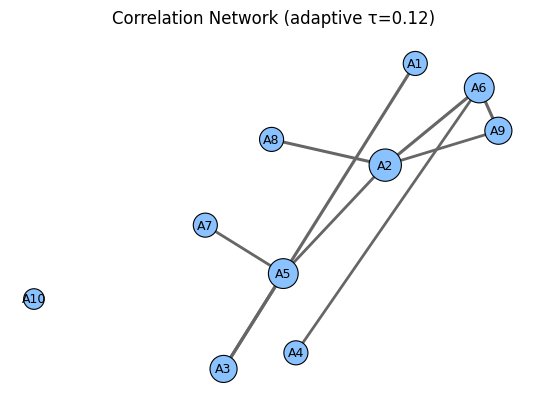

In [3]:
# Visualization for correlation network
pos = nx.spring_layout(G_corr, seed=1)
deg = dict(G_corr.degree())
node_sizes = [220 + 80*deg[n] for n in G_corr.nodes()]

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.set_facecolor('white')

edge_widths = [1.5 + 4*abs(d['weight']) for _,_,d in G_corr.edges(data=True)]
nx.draw_networkx_edges(G_corr, pos, ax=ax, width=edge_widths, edge_color='0.4')
nx.draw_networkx_nodes(G_corr, pos, ax=ax, node_size=node_sizes, node_color='#89C2FF', edgecolors='black', linewidths=0.8)
nx.draw_networkx_labels(G_corr, pos, ax=ax, font_size=9)

ax.set_title(f"Correlation Network (adaptive τ={tau:.2f})")
ax.set_axis_off()
plt.show()


**Example 2:** Interbank loans

This is an example of **directed and weighted** graph. Edge $u\to v$ means **loan from $u$ to $v$** with weight = loan amount. We will call these weights **strengths**, such that:

- **Out-strength:** $s^{{out}}(v) = \sum_u w_{v u}$,  
- **In-strength:**  $s^{{in}}(v)  = \sum_u w_{u v}$,  
- **Net position:** $s^{{net}}(v) = s^{{out}}(v) - s^{{in}}(v)$.


Let's produce some synthetic data, calculate strengths, and summarize all:

In [4]:
# Synthetic data
n_banks = 8
banks = [f"B{i+1}" for i in range(n_banks)]
rng = np.random.default_rng(7)
possible_edges = [(u, v) for u in banks for v in banks if u != v]

m_edges = 16
chosen = [possible_edges[i] for i in rng.choice(len(possible_edges), size=m_edges, replace=False)]
amounts = rng.uniform(1e3, 5e4, size=m_edges)

G_loans = nx.DiGraph()
for (u, v), amt in zip(chosen, amounts):
    G_loans.add_edge(u, v, weight=float(amt))

# Strengths
in_strength  = dict(G_loans.in_degree(weight='weight'))
out_strength = dict(G_loans.out_degree(weight='weight'))
net = {n: out_strength.get(n,0.0) - in_strength.get(n,0.0) for n in G_loans.nodes()}
summary = pd.DataFrame({"out_strength": out_strength, "in_strength": in_strength, "net": net}).sort_values("net", ascending=False)
display(summary.style.format("{:,.0f}"))


,out_strength,in_strength,net
B7,"146,478","28,940","117,538"
B6,"76,777",0,"76,777"
B3,"72,171","39,840","32,330"
B1,"42,565","29,383","13,182"
B4,"57,679","86,676","-28,998"
B5,"13,128","64,527","-51,398"
B8,"2,748","80,946","-78,197"
B2,"8,850","90,084","-81,234"


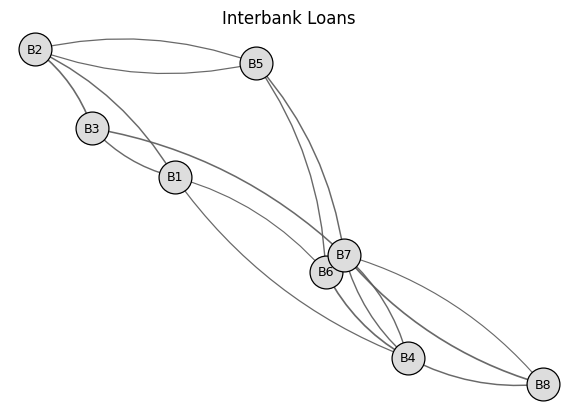

In [5]:
# Visualization
pos = nx.spring_layout(G_loans, seed=2)
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.set_facecolor('white')

nx.draw_networkx_nodes(G_loans, pos, ax=ax, node_size=560, node_color='#DDDDDD', edgecolors='black', linewidths=0.9)
nx.draw_networkx_labels(G_loans, pos, ax=ax, font_size=9)

total_w = max(G_loans.size(weight='weight'), 1.0)
for u, v, d in G_loans.edges(data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    width = max(0.8, 0.8 + 3.5 * d['weight'] / total_w)
    arrow = FancyArrowPatch((x0, y0), (x1, y1),
                            connectionstyle="arc3,rad=0.15",
                            arrowstyle='-|>',
                            mutation_scale=12,
                            linewidth=width,
                            color='0.35',
                            alpha=0.9)
    ax.add_patch(arrow)

ax.set_title("Interbank Loans")
ax.set_axis_off()
plt.show()


## **2. Adjacency Matrix**

A **graph** can be represented in several equivalent ways. This property can be extremely relevant when we want to extract information from some graph structure. Importantly, one of the most common and mathematically convenient forms of represent a graph involves the **adjacency matrix**.

For a graph $G = (V, E)$ with $ n = |V| $ vertices, the **adjacency matrix** is an $ n \times n $ matrix $ A = [a_{ij}] $, where:

$$
a_{ij} =
\begin{cases}
1, & \text{if \ edge \ from \ vertex}\ i \text{ \ to \ vertex}\ j \\
0, & \text{otherwise}
\end{cases}
$$

Each row and column corresponds to a vertex in \( V \).


This means, for instance, that for **undirected** graphs, the adjacency matrix is **symmetric**:

$$
a_{ij} = a_{ji}
$$

Thus, the number of edges is:

$$
|E| = \frac{1}{2} \sum_{i,j} a_{ij}
$$

For example:

$$
V = \{A, B, C\}, \quad E = \{(A, B), (B, C)\}
$$

$$
A =
\begin{bmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$


\
For **directed** graphs, on the other hand, $ a_{ij} = 1 $ if there is an edge **from** $i$ **to** $j$, and $a_{ji}$ may differ from $a_{ij}$:

$$
V = \{A, B, C\}, \quad E = \{(A, B), (B, C)\}
$$

$$
A =
\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & 1 \\
0 & 0 & 0
\end{bmatrix}
$$

This way, the **adjacency matrix** captures the **directionality** of relationships.


\
In **weighted** graphs, the entries of the adjacency matrix contain the edge weights instead of binary values:

$$
a_{ij} =
\begin{cases}
w(i, j), & \text{if \ edge \ between}\ i \ \text{ and }\ j \\
0, & \text{otherwise}
\end{cases}
$$

For example,

$$
w(A,B) = 0.8, \quad w(B,C) = 0.3
$$

$$
A =
\begin{bmatrix}
0 & 0.8 & 0 \\
0 & 0 & 0.3 \\
0 & 0 & 0
\end{bmatrix}
$$



\
There is, thus, a lot of information we can gather from the **adjacency matrix**, even for very simple graphs:

| if... | then... |
|-----------|----------|
| $ A $ is **symmetric** | Graph is undirected |
| $ A $ is **asymmetric** | Graph is directed |
| **Nonzero entries** | Represent existing edges |
| **Diagonal entries** | Represent self-loops |
| $A^k_{ij}$ | Number (or total weight) of paths of length $k$ from $i$ to $j$ |


**What is the relevance of $A$ in Network Analysis?**

The adjacency matrix is central to network computations, as we will explore through this and next modules:

- Degree of a node $i$: $k_i = \sum_j a_{ij}$
- Path counts and reachability via matrix powers
- Eigenvector-based measures (e.g., **centrality**, **PageRank**)
- Efficient storage and manipulation for algorithms


\
**How can I compute the adjacency matrix in python?**

Turns out there is a very convenient way to create and inspect adjacency matrices in python using the networkx package:


In [6]:
import networkx as nx

G = nx.Graph()
G.add_edges_from([("A", "B"), ("B", "C")])
A = nx.to_numpy_array(G, nodelist=["A", "B", "C"])
print(A)

[[0. 1. 0.]
 [1. 0. 1.]
 [0. 1. 0.]]


Importantly, we can also do this for any defined graph, such as our previous example of interbank loans:

In [7]:
A_loans = nx.to_numpy_array(G_loans)
print(A_loans)

[[    0.         49779.51388829     0.             0.
      0.          3153.15839011     0.         23844.09524094]
 [    0.             0.         26191.76468338     0.
  31486.78224262     0.             0.             0.        ]
 [    0.         25346.79833428     0.         39840.43404147
  49459.04723641     0.             0.         31832.08647006]
 [    0.             0.             0.             0.
      0.         26229.5521933  45941.22088645     0.        ]
 [    0.             0.          2748.33365991     0.
      0.             0.             0.             0.        ]
 [    0.         11550.12621354     0.             0.
      0.             0.         31014.44060938     0.        ]
 [    0.             0.             0.             0.
      0.             0.             0.          8850.38965903]
 [    0.             0.             0.             0.
      0.             0.         13128.23117934     0.        ]]


## **3. Degrees in a Network**

The **degree** of a node is one of the most fundamental concepts in graph theory.  It measures how many other nodes a given node is directly connected to.

\
For a graph $G = (V, E)$:

- The **degree** of a vertex $i$, denoted $k_i$, is the number of edges incident to $i$.

$$
k_i = \sum_{j} a_{ij}
$$

where $A = [a_{ij}]$ is the adjacency matrix.

\
In a **directed** graph, each node has two degree measures:

- **Out-degree:** number of outgoing edges  
  $$
  k_i^{\text{out}} = \sum_j a_{ij}
  $$
- **In-degree:** number of incoming edges  
  $$
  k_i^{\text{in}} = \sum_j a_{ji}
  $$

\
For **undirected** graphs, these are identical: $k_i^{\text{in}} = k_i^{\text{out}} = k_i$.


\
The **degree distribution** describes how degrees are spread across all nodes in the network.

$$
P(k) = \frac{\text{Number \ of \ nodes \ with \ degree }\ k}{|V|}
$$


This function characterizes the **topology** of the network:
- In **random graphs**, most nodes have similar degrees.  
- In **real-world networks**, degree distributions are often **skewed** or **heavy-tailed** — a few nodes have very high degrees (“hubs”).


\
**Real-world networks are sparse:**

In most real-world systems, each node connects to only a **tiny fraction** of all possible nodes.  
If $ n = |V| $ is large, a network with an average degree $ \langle k \rangle $ has far fewer edges than the complete graph.

\
We know that the **maximum possible number of edges** in an undirected network is:

$$
E_{\text{max}} = \frac{n(n-1)}{2}
$$

But the **actual number of edges** is usually much smaller:

$$
|E| = \frac{1}{2} \sum_i k_i
$$

Thus, real networks are typically **sparse**, and the connections are not as trivial. Let's explore this concept further.



## **4. Connectedness in Networks**

The **connectedness** of a network captures how easily information, value, or influence can flow between its nodes.  
It reflects the **overall integrity** of the system —whether all parts are reachable, or if the network breaks into isolated clusters.

\
In an **undirected graph**, two nodes are said to be **connected** if there exists a **path** between them — a sequence of edges linking one to the other.

A **connected component** is a **maximal set of nodes** in which every pair of nodes is connected by some path.

- A graph is **connected** if it has exactly one connected component.  
- If it has multiple components, the graph is **disconnected**.

\
**Examples:**
- A network of banks where every bank can reach every other via credit exposures → **connected**.  
- If one bank or cluster is isolated → **disconnected**.



### 4.1. Density

The **density** ($D$) of a graph measures how many edges exist compared to the maximum possible number of edges.

For an **undirected** graph:

$$
D = \frac{2|E|}{n(n-1)}
$$

For a **directed** graph:

$$
D = \frac{|E|}{n(n-1)}
$$

where:
- $|E|$ is the number of edges,  
- $n = |V|$ is the number of nodes.

Values of $D$ can range between **0** (no edges) and **1** (fully connected, or complete graph).

A **sparse network** therefore has $D \ll 1$.



### 4.2. Average Degree

An important measure of connectedness is the **average degree**:

$$
\langle k \rangle = \frac{1}{n} \sum_i k_i = \frac{2|E|}{n}
$$

This tells us, on average, how many neighbors each node has.  It is directly related to network density:

$$
D = \frac{\langle k \rangle}{n - 1}
$$


### 4.3. Path-Based Connectedness

While degree and density capture **local** connections, path-based metrics capture **global reachability**. These metrics include:

- **Average path length**: the mean number of steps along the shortest paths between all pairs of nodes.
- **Diameter**: the longest shortest path in the network.
- **Reachability ratio**: the fraction of node pairs that are connected by a path.

These measures indicate **how efficiently** the network allows movement or transmission across its structure. 

\
**Why does information transimission in the network matter?**

There are a lot of instances in which we are interested in unveiling how fast information propagates through a network. For example, in a financial system:

- **High connectedness** → efficient transmission of information, but also higher **systemic risk** (contagion).  
- **Low connectedness** → segmentation or fragmentation, reducing risk transmission but limiting coordination.  

\
Hence, connectedness measures based on **degree and density** provide key insight into how **robust** or **vulnerable** a network may be. Let's illustrate these concepts visually:


**Connectedness of a financial system**

To illustrate how important connectedness can be in a network, let's build a simple example with interbank loan exposures. We will synthetically create an **undirected network**, where banks have mutual exposures; and a **directed** one, where we can observe the flow of money. 

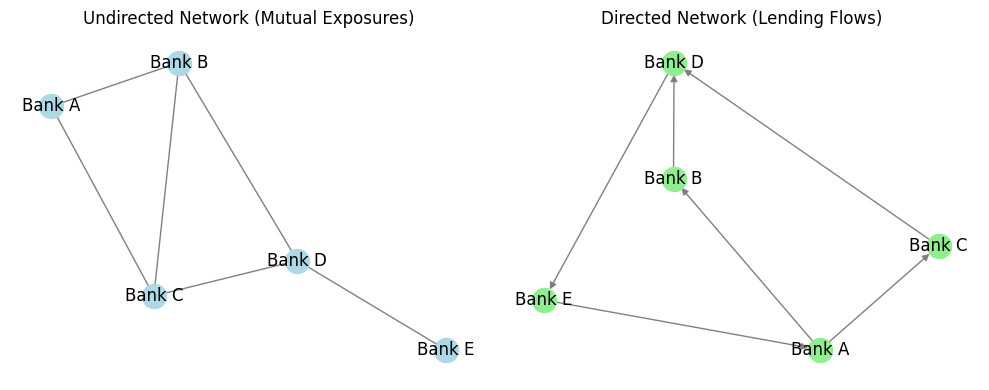

🔹 Undirected Interbank Network
Nodes: 5, Edges: 6
Average degree: 2.40
Density: 0.600

🔸 Directed Interbank Network
Nodes: 5, Edges: 6
Average degree: 2.40
Density: 0.300


In [8]:
# --- Undirected Network: Mutual Credit Exposures ---
G_undirected = nx.Graph()

edges_undirected = [
    ("Bank A", "Bank B"),
    ("Bank A", "Bank C"),
    ("Bank B", "Bank C"),
    ("Bank B", "Bank D"),
    ("Bank C", "Bank D"),
    ("Bank D", "Bank E"),
]

G_undirected.add_edges_from(edges_undirected)

# --- Directed Network: Lending Flows ---
G_directed = nx.DiGraph()

edges_directed = [
    ("Bank A", "Bank B"),
    ("Bank A", "Bank C"),
    ("Bank B", "Bank D"),
    ("Bank C", "Bank D"),
    ("Bank D", "Bank E"),
    ("Bank E", "Bank A"),  
]

G_directed.add_edges_from(edges_directed)

# --- Connectedness measures ---
def network_summary(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_deg = sum(dict(G.degree()).values()) / n
    density = nx.density(G)
    return n, m, avg_deg, density

# --- Visualization ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
pos1 = nx.spring_layout(G_undirected, seed=1)
nx.draw_networkx(G_undirected, pos=pos1, with_labels=True, node_color="lightblue", edge_color="gray")
plt.title("Undirected Network (Mutual Exposures)")
plt.axis("off")

plt.subplot(1, 2, 2)
pos2 = nx.spring_layout(G_directed, seed=1)
nx.draw_networkx(G_directed, pos=pos2, with_labels=True, node_color="lightgreen", edge_color="gray", arrows=True)
plt.title("Directed Network (Lending Flows)")
plt.axis("off")

plt.tight_layout()
plt.show()


# --- Compute metrics for both networks ---
n_u, m_u, avg_u, dens_u = network_summary(G_undirected)
n_d, m_d, avg_d, dens_d = network_summary(G_directed)

print("🔹 Undirected Interbank Network")
print(f"Nodes: {n_u}, Edges: {m_u}")
print(f"Average degree: {avg_u:.2f}")
print(f"Density: {dens_u:.3f}\n")

print("🔸 Directed Interbank Network")
print(f"Nodes: {n_d}, Edges: {m_d}")
print(f"Average degree: {avg_d:.2f}")
print(f"Density: {dens_d:.3f}")


## **5. Conclusion**

Well done! In this lesson we have introduced network theory, together with the basic graphs and representations. Importantly, we have also introduced a bunch of metrics that are going to be important down the road to assess networks and their ability to propagate information.

In the next lesson, we will dig deeper into more advance types of networks that help us deal with real-world problems.


---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
